In [307]:
import pandas as pd 
import numpy as np 

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [308]:
# Load the dataset
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
print(df.head(10))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [309]:
# step 2: Check missing values with percentage of each columns
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [310]:
# step 3: Numerical vs Categorical Columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

In [311]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [312]:
print((df['TotalCharges'] == " ").sum())

11


In [313]:
print(df["TotalCharges"].dtype)

object


In [314]:
#  Convert to Numeric 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors="coerce")
# The errors="coerce" argument converts any non-numeric values into NaN, 
# which is a professional and safe approach.

In [315]:
print(df["TotalCharges"].dtype)

float64


In [316]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [317]:
# Replace Blank string with NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

In [318]:
print((df['TotalCharges'] == " ").sum())

0


In [319]:
# After replacing there is 11 null values in TotalCharges feature.
print(df["TotalCharges"].isnull().sum())

11


In [320]:
# Convert to Numeric 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors="coerce")
# The errors="coerce" argument converts any non-numeric values into NaN, 
# which is a professional and safe approach.

In [321]:
# verify data types
print(df['TotalCharges'].dtype)

float64


In [322]:
# Chech missing values again
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [323]:
df.dropna()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [324]:
df.shape

(7043, 21)

missing values still exist so we fill these values with 
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [325]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [326]:
# verify
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**No onward we will prepare data for training**

In [327]:
# Remove customerID because this feature has no predictive value.
df.drop(columns='customerID', inplace=True)
df.shape

(7043, 20)

**Separate Features and Target***

In [328]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [329]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

In [330]:
print("Numerical Features:")
print(numerical_features)

print()

print("Categorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


***Perform the Cleaning Again***

In [331]:
df["TotalCharges"] = df["TotalCharges"].str.strip()

df["TotalCharges"] = df["TotalCharges"].replace("", np.nan)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

df.drop(columns=["customerID"], inplace=True)

AttributeError: Can only use .str accessor with string values!

In [ ]:
df["TotalCharges"].dtype

dtype('float64')

In [ ]:
# Create X and y
X = df.drop('Churn', axis=1)

y = df["Churn"]

In [ ]:
# Create Feature Lists
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features: ",numerical_features)
print("Categorical Features: ",categorical_features)

Numerical Features:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Numerical Pipeline**

In [ ]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

**Categorical Pipeline**

In [ ]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
print(categorical_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])


In [ ]:
print(numeric_pipeline)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


**Create the Preprocessor**

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

**Verify Preprocessor**

In [ ]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup'

**First we understand and clean the dataset.**
**Now onward we train and test the model on cleaned dataset**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    stratify=y
)

In [ ]:
results = []

**Logistic Regression Model**

In [ ]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

In [333]:
model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_pred[:10])
print(y_probability[:5])

(5282, 19)
(1761, 19)
['No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes']
[[0.83323867 0.16676133]
 [0.94851436 0.05148564]
 [0.94668899 0.05331101]
 [0.28460943 0.71539057]
 [0.98285796 0.01714204]]


**Model Evaluation**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
# Accuracy Measure
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8064


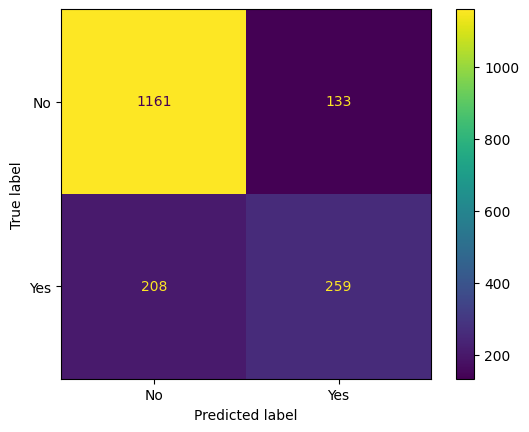

In [ ]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)
plt.show()

In [ ]:
# Precision
precision = precision_score(
    y_test,
    y_pred,
    pos_label="Yes"
)
print(f"Precision: {precision:.4f}")

Precision: 0.6607


In [ ]:
# Recall
recall = recall_score(
    y_test,
    y_pred,
    pos_label = "Yes"
)

print(f"Recall: {recall:.4f}")

Recall: 0.5546


In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.6030


In [ ]:
# Classification Report 

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.90      0.87      1294
         Yes       0.66      0.55      0.60       467

    accuracy                           0.81      1761
   macro avg       0.75      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761



In [ ]:
# ROC-AUC Score

y_prob = model.predict_proba(X_test)
y_prob

array([[0.83323867, 0.16676133],
       [0.94851436, 0.05148564],
       [0.94668899, 0.05331101],
       ...,
       [0.82310963, 0.17689037],
       [0.60054854, 0.39945146],
       [0.52833563, 0.47166437]], shape=(1761, 2))

In [ ]:
y_prob_yes = y_prob[:, 1]
y_prob_yes

array([0.16676133, 0.05148564, 0.05331101, ..., 0.17689037, 0.39945146,
       0.47166437], shape=(1761,))

In [ ]:
roc_auc = roc_auc_score(y_test, y_prob_yes)

print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.8466


In [ ]:
# ROC Curve 
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_yes,
    pos_label="Yes"
)

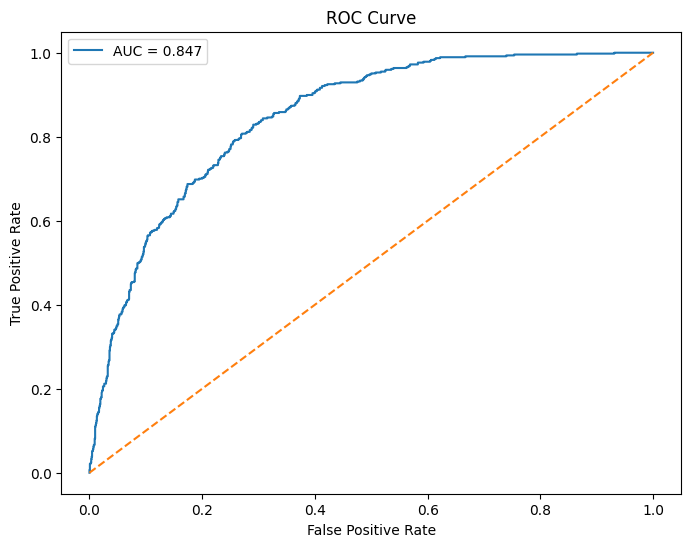

In [ ]:
# plot it:
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
})

In [ ]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8063600227143668,
  'Precision': 0.6607142857142857,
  'Recall': 0.5546038543897216,
  'F1 Score': 0.6030267753201397,
  'ROC-AUC': 0.8466054827254103}]

**Now onward we use Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [ ]:
# Train the model
decision_tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Predicted class labels
dt_y_pred = decision_tree_model.predict(X_test)

# Predicted probabilities
dt_y_prob = decision_tree_model.predict_proba(X_test)

In [ ]:
print(dt_y_pred.shape)
print(dt_y_pred[:10])

print(dt_y_prob.shape)
print(dt_y_prob[:5])

(1761,)
['No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes']
(1761, 2)
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]


In [ ]:
dt_accuracy = accuracy_score(y_test, dt_y_pred)

dt_precision = precision_score(
    y_test,
    dt_y_pred,
    pos_label="Yes"
)

dt_recall = recall_score(
    y_test,
    dt_y_pred,
    pos_label="Yes"
)

dt_f1 = f1_score(
    y_test,
    dt_y_pred,
    pos_label="Yes"
)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

print(classification_report(y_test, dt_y_pred))

Accuracy : 0.7428
Precision: 0.5154
Recall   : 0.5011
F1 Score : 0.5081
              precision    recall  f1-score   support

          No       0.82      0.83      0.83      1294
         Yes       0.52      0.50      0.51       467

    accuracy                           0.74      1761
   macro avg       0.67      0.67      0.67      1761
weighted avg       0.74      0.74      0.74      1761



In [ ]:
dt_y_prob_yes = dt_y_prob[:, 1]

dt_auc = roc_auc_score(
    y_test,
    dt_y_prob_yes
)

print(f"ROC-AUC: {dt_auc:.4f}")

ROC-AUC: 0.6651


In [ ]:
results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1,
    "ROC-AUC": dt_auc
})

In [ ]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8063600227143668,
  'Precision': 0.6607142857142857,
  'Recall': 0.5546038543897216,
  'F1 Score': 0.6030267753201397,
  'ROC-AUC': 0.8466054827254103},
 {'Model': 'Logistic Regression',
  'Accuracy': 0.8063600227143668,
  'Precision': 0.6607142857142857,
  'Recall': 0.5546038543897216,
  'F1 Score': 0.6030267753201397,
  'ROC-AUC': 0.8466054827254103},
 {'Model': 'Decision Tree',
  'Accuracy': 0.7427597955706985,
  'Precision': 0.5154185022026432,
  'Recall': 0.5010706638115632,
  'F1 Score': 0.50814332247557,
  'ROC-AUC': 0.665142032573333}]

**Now onward we use Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42
        ))
    ]
)

In [ ]:
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
rf_y_pred = random_forest_model.predict(X_test)

rf_y_prob = random_forest_model.predict_proba(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_y_pred)

print(f"Random Forest Accuracy : {rf_accuracy:.4f}")

rf_precision = precision_score(
    y_test,
    rf_y_pred,
    pos_label="Yes"
)

print(f"Random Forest Precision : {rf_precision:.4f}")

rf_recall = recall_score(
    y_test,
    rf_y_pred,
    pos_label="Yes"
)

print(f"Random Forest Recall : {rf_recall:.4f}")

rf_f1 = f1_score(
    y_test,
    rf_y_pred,
    pos_label="Yes"
)

print(f"Random Forest F1 Score : {rf_f1:.4f}")

print(classification_report(y_test, rf_y_pred))

Random Forest Accuracy : 0.7808
Random Forest Precision : 0.6147
Random Forest Recall : 0.4647
Random Forest F1 Score : 0.5293
              precision    recall  f1-score   support

          No       0.82      0.89      0.86      1294
         Yes       0.61      0.46      0.53       467

    accuracy                           0.78      1761
   macro avg       0.72      0.68      0.69      1761
weighted avg       0.77      0.78      0.77      1761



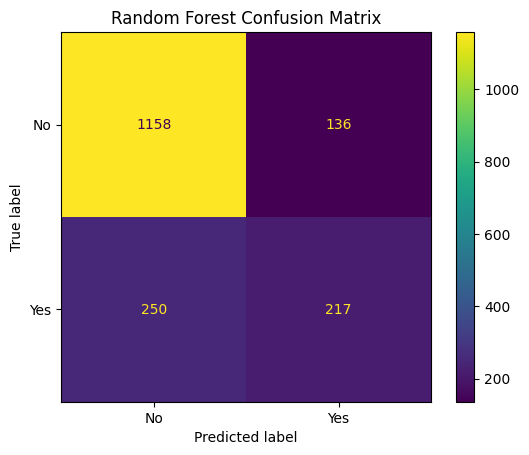

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_y_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
rf_y_prob_yes = rf_y_prob[:, 1]

rf_auc = roc_auc_score(
    y_test,
    rf_y_prob_yes
)

print(f"Random Forest ROC-AUC : {rf_auc:.4f}")

In [ ]:
rf_y_prob_yes = rf_y_prob[:, 1]

rf_auc = roc_auc_score(
    y_test,
    rf_y_prob_yes
)

print(f"Random Forest ROC-AUC : {rf_auc:.4f}")

Random Forest ROC-AUC : 0.8228


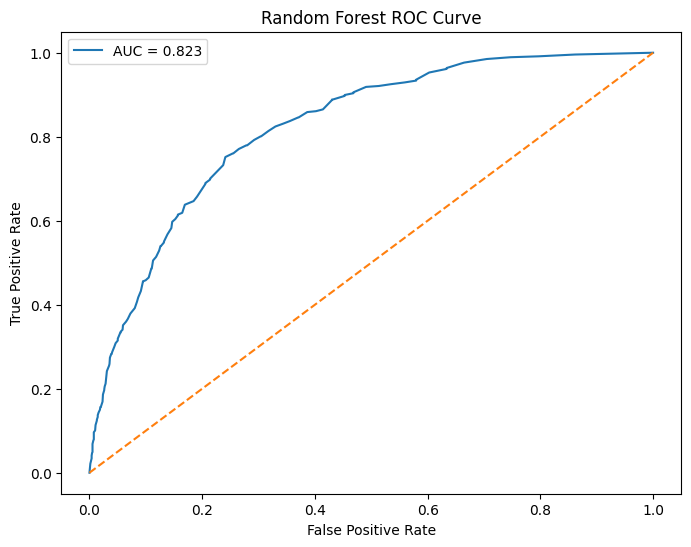

In [ ]:
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_y_prob_yes,
    pos_label="Yes"
)

plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"AUC = {rf_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_auc,
        rf_auc
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806360,0.660714,0.554604,0.603027,0.846605
1,Decision Tree,0.742760,0.515419,0.501071,0.508143,0.665142
2,Random Forest,0.780806,0.614731,0.464668,0.529268,0.822766


In [ ]:
rf_classifier = random_forest_model.named_steps["classifier"]

print(rf_classifier.feature_importances_)

[0.01909521 0.13654136 0.13618524 0.16136876 0.018209   0.01834935
 0.0144687  0.01455654 0.0122021  0.01210473 0.00316325 0.0030972
 0.01348263 0.00296767 0.01351445 0.01231218 0.02934556 0.0017727
 0.03293844 0.00155271 0.01214627 0.0173144  0.0015483  0.01291461
 0.01615195 0.0029122  0.01165322 0.02523449 0.00378527 0.01235012
 0.01090618 0.00148286 0.01148786 0.01132433 0.00558931 0.01181607
 0.04971106 0.0107555  0.0142217  0.01634828 0.01577878 0.01176459
 0.01253471 0.03228542 0.01075475]


In [ ]:
results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_auc
})

In [ ]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8063600227143668,
  'Precision': 0.6607142857142857,
  'Recall': 0.5546038543897216,
  'F1 Score': 0.6030267753201397,
  'ROC-AUC': 0.8466054827254103},
 {'Model': 'Logistic Regression',
  'Accuracy': 0.8063600227143668,
  'Precision': 0.6607142857142857,
  'Recall': 0.5546038543897216,
  'F1 Score': 0.6030267753201397,
  'ROC-AUC': 0.8466054827254103},
 {'Model': 'Decision Tree',
  'Accuracy': 0.7427597955706985,
  'Precision': 0.5154185022026432,
  'Recall': 0.5010706638115632,
  'F1 Score': 0.50814332247557,
  'ROC-AUC': 0.665142032573333},
 {'Model': 'Decision Tree',
  'Accuracy': 0.7427597955706985,
  'Precision': 0.5154185022026432,
  'Recall': 0.5010706638115632,
  'F1 Score': 0.50814332247557,
  'ROC-AUC': 0.665142032573333},
 {'Model': 'Random Forest',
  'Accuracy': 0.7808063600227144,
  'Precision': 0.6147308781869688,
  'Recall': 0.46466809421841543,
  'F1 Score': 0.5292682926829269,
  'ROC-AUC': 0.8227662510880392},
 {'Model

**Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

In [ ]:
gradient_boosting_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
gb_y_pred = gradient_boosting_model.predict(X_test)

gb_y_prob = gradient_boosting_model.predict_proba(X_test)

In [ ]:
gb_accuracy = accuracy_score(y_test, gb_y_pred)

print(f"Gradient Boosting Accuracy : {gb_accuracy:.4f}")

gb_precision = precision_score(
    y_test,
    gb_y_pred,
    pos_label="Yes"
)

print(f"Gradient Boosting Precision : {gb_precision:.4f}")

gb_recall = recall_score(
    y_test,
    gb_y_pred,
    pos_label="Yes"
)

print(f"Gradient Boosting Recall : {gb_recall:.4f}")

gb_f1 = f1_score(
    y_test,
    gb_y_pred,
    pos_label="Yes"
)

print(f"Gradient Boosting F1 Score : {gb_f1:.4f}")

print(classification_report(y_test, gb_y_pred))

Gradient Boosting Accuracy : 0.8001
Gradient Boosting Precision : 0.6638
Gradient Boosting Recall : 0.4989
Gradient Boosting F1 Score : 0.5697
              precision    recall  f1-score   support

          No       0.83      0.91      0.87      1294
         Yes       0.66      0.50      0.57       467

    accuracy                           0.80      1761
   macro avg       0.75      0.70      0.72      1761
weighted avg       0.79      0.80      0.79      1761



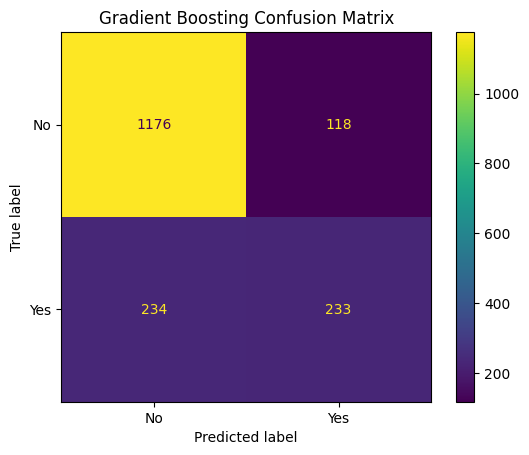

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_y_pred
)

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [ ]:
gb_y_prob_yes = gb_y_prob[:, 1]

gb_auc = roc_auc_score(
    y_test,
    gb_y_prob_yes
)

print(f"Gradient Boosting ROC-AUC : {gb_auc:.4f}")

Gradient Boosting ROC-AUC : 0.8461


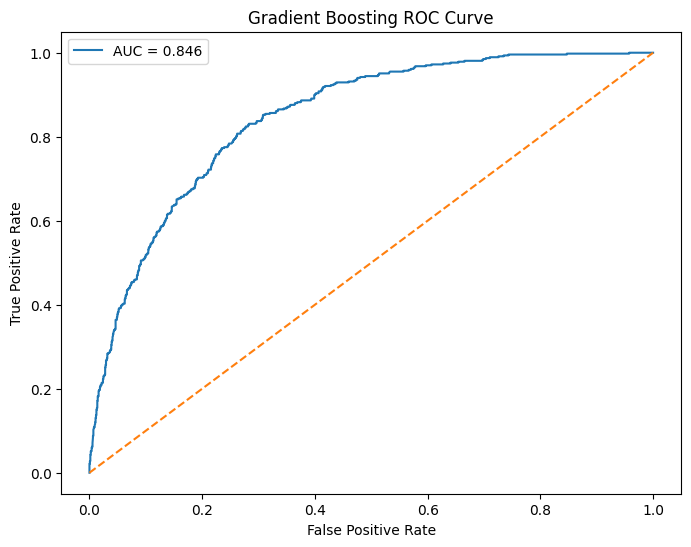

In [ ]:
gb_fpr, gb_tpr, _ = roc_curve(
    y_test,
    gb_y_prob_yes,
    pos_label="Yes"
)

plt.figure(figsize=(8,6))

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"AUC = {gb_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve")
plt.legend()

plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1,
        gb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_auc,
        rf_auc,
        gb_auc
    ]
})

comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806360,0.660714,0.554604,0.603027,0.846605
3,Gradient Boosting,0.800114,0.663818,0.498929,0.569682,0.846071
2,Random Forest,0.780806,0.614731,0.464668,0.529268,0.822766
1,Decision Tree,0.742760,0.515419,0.501071,0.508143,0.665142


**Hyperparameter Tuning with GridSearchCV**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier())
    ]
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Create the Parameter Grid
rf_param_grid = {
    "classifier__n_estimators": [100, 200],

    "classifier__max_depth": [None, 10, 20],

    "classifier__min_samples_split": [2, 5],

    "classifier__min_samples_leaf": [1, 2]
}

In [ ]:
# Create GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=random_forest_model,

    param_grid=rf_param_grid,

    cv=5,

    scoring="roc_auc",

    n_jobs=-1,

    verbose=2
)

In [ ]:
# Start Training 
rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [ ]:
print(rf_grid_search.best_params_)

{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [ ]:
print(rf_grid_search.best_score_)

0.8432357546423199


In [ ]:
best_rf_model = rf_grid_search.best_estimator_

In [ ]:
best_rf_model = rf_grid_search.best_estimator_
best_rf_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Make Predictions
best_rf_pred = best_rf_model.predict(X_test)

best_rf_prob = best_rf_model.predict_proba(X_test)

In [ ]:
best_rf_accuracy = accuracy_score(y_test, best_rf_pred)

print(best_rf_accuracy)

best_rf_precision = precision_score(
    y_test,
    best_rf_pred,
    pos_label="Yes"
)

best_rf_recall = recall_score(
    y_test,
    best_rf_pred,
    pos_label="Yes"
)

best_rf_f1 = f1_score(
    y_test,
    best_rf_pred,
    pos_label="Yes"
)

print(classification_report(y_test, best_rf_pred))

#roc_auc_score()

# ConfusionMatrixDisplay()

# ROC Curve

0.8018171493469619
              precision    recall  f1-score   support

          No       0.83      0.91      0.87      1294
         Yes       0.67      0.50      0.57       467

    accuracy                           0.80      1761
   macro avg       0.75      0.71      0.72      1761
weighted avg       0.79      0.80      0.79      1761



In [ ]:
from sklearn.metrics import roc_auc_score

# Probability of the positive class ("Yes")
best_rf_prob_yes = best_rf_prob[:, 1]

best_rf_auc = roc_auc_score(
    y_test,
    best_rf_prob_yes
)

print(f"Tuned Random Forest ROC-AUC: {best_rf_auc:.4f}")

Tuned Random Forest ROC-AUC: 0.8422


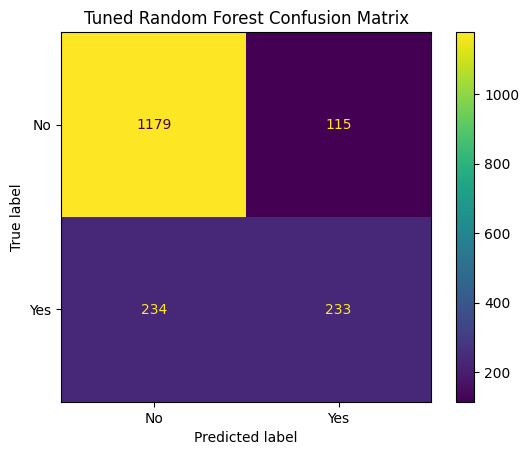

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_rf_pred
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

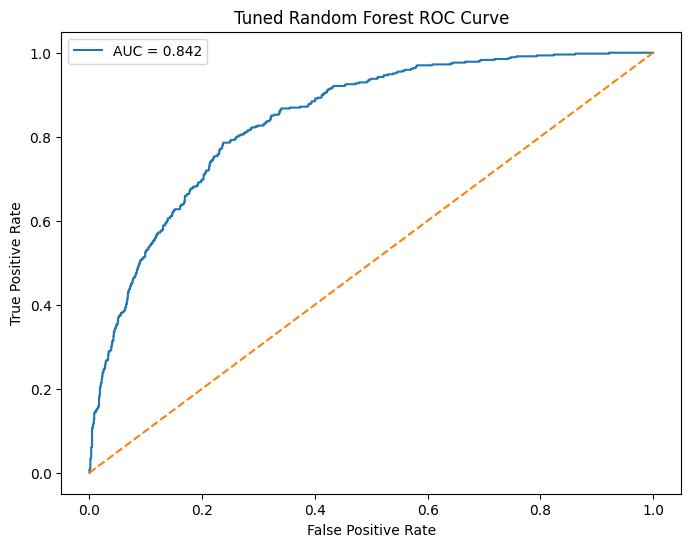

In [ ]:
from sklearn.metrics import roc_curve

best_rf_fpr, best_rf_tpr, thresholds = roc_curve(
    y_test,
    best_rf_prob_yes,
    pos_label="Yes"
)

plt.figure(figsize=(8,6))

plt.plot(
    best_rf_fpr,
    best_rf_tpr,
    label=f"AUC = {best_rf_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Random Forest ROC Curve")
plt.legend()

plt.show()

In [ ]:
print(type(best_rf_model))
print(best_rf_pred.shape)
print(best_rf_prob.shape)

<class 'sklearn.pipeline.Pipeline'>
(1761,)
(1761, 2)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)

best_rf_accuracy = accuracy_score(y_test, best_rf_pred)

best_rf_precision = precision_score(
    y_test,
    best_rf_pred,
    pos_label="Yes"
)

best_rf_recall = recall_score(
    y_test,
    best_rf_pred,
    pos_label="Yes"
)

best_rf_f1 = f1_score(
    y_test,
    best_rf_pred,
    pos_label="Yes"
)

best_rf_auc = roc_auc_score(
    y_test,
    best_rf_prob[:,1]
)

print(f"Accuracy : {best_rf_accuracy:.4f}")
print(f"Precision: {best_rf_precision:.4f}")
print(f"Recall   : {best_rf_recall:.4f}")
print(f"F1 Score : {best_rf_f1:.4f}")
print(f"ROC-AUC  : {best_rf_auc:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, best_rf_pred))

Accuracy : 0.8018
Precision: 0.6695
Recall   : 0.4989
F1 Score : 0.5718
ROC-AUC  : 0.8422

Classification Report

              precision    recall  f1-score   support

          No       0.83      0.91      0.87      1294
         Yes       0.67      0.50      0.57       467

    accuracy                           0.80      1761
   macro avg       0.75      0.71      0.72      1761
weighted avg       0.79      0.80      0.79      1761



**Retrained the Logistic Regression model which is the best model**

In [337]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create the pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [338]:
# Saving the model
import joblib


joblib.dump(
    logistic_model,
    "../models/customer_churn_pipeline.pkl"
)

print("✅ Logistic Regression pipeline saved successfully!")

✅ Logistic Regression pipeline saved successfully!


In [339]:
loaded_model = joblib.load("../models/customer_churn_pipeline.pkl")

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [340]:
import sklearn
print(sklearn.__version__)

1.7.1


In [341]:
import joblib
print(joblib.__version__)

1.5.1


In [342]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
